In [17]:
%matplotlib widget

In [ ]:
%pip install openpmd_viewer openpmd-api

In [75]:
from matplotlib import pyplot as plt
import numpy as np
import openpmd_viewer as ov
from openpmd_viewer import OpenPMDTimeSeries
import os

path = os.path.join(os.environ['PSCRATCH'], 'diags', 'test')
print(path)
ts_2d = OpenPMDTimeSeries(path)


    
    



/pscratch/sd/l/leosyam/diags/test


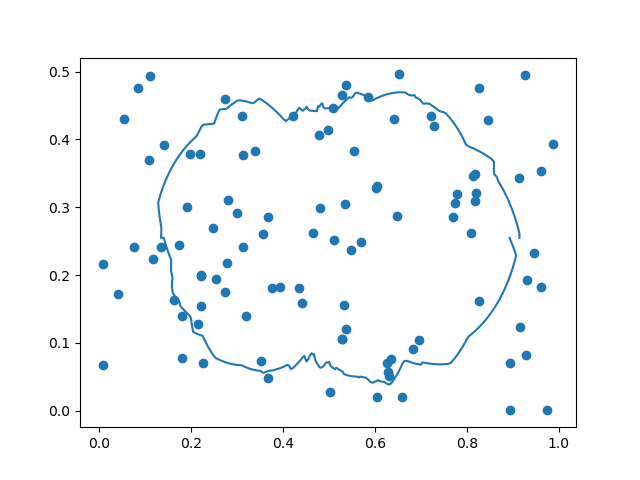

In [82]:
angs = np.linspace(0, np.pi, 200)
vecs = []
for i in angs:
    vecs.append([np.cos(i), np.sin(i)])
vecs = np.array(vecs).T
def loopfrompoints(pts, range_percent):
    center = np.mean(pts, axis=0)
    pts2 = pts - center
    dots = np.matmul(pts2, vecs)
    dots.sort(axis=0)
    mid = dots.shape[0] // 2
    off = int((dots.shape[0] * range_percent) / 2)
    set1 = vecs * dots[mid + off]
    set2 = vecs * dots[mid - off]
    return np.append(set1, set2, axis=1).T + center
    

points = np.random.random((100, 2))
points[:, 1] *= 0.5
loop = loopfrompoints(points, 0.8)

plt.close()
plt.figure()
plt.scatter(points[:, 0], points[:, 1])
plt.plot(loop[:, 0], loop[:, 1])
plt.show()
